# Lab 3: Facebook Prophet — Forecasting the Daily Delhi Climate Dataset (Student Version)

## Objective
Apply Prophet's decomposable forecasting framework to the Daily Climate Delhi Dataset:
1. Environment setup and data ingestion.
2. Exploratory Data Analysis and schema preparation.
3. Model trials: baseline, trend, seasonality, and regressors.
4. Visualization: forecast components and changepoints.
5. Cross-validation and performance metrics.
6. Forecasting with prediction intervals.

### Task 1: Import Necessary Libraries
Import Prophet alongside the standard data science stack and Prophet's diagnostic utilities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from prophet:
# - Prophet (from prophet)
# - plot_forecast_component (from prophet.plot)
# - cross_validation, performance_metrics (from prophet.diagnostics)

# Your imports here:
from prophet import Prophet
from prophet.plot import plot_forecast_component
from prophet.diagnostics import cross_validation, performance_metrics

### Task 2: Load and Inspect the Dataset
We use the `sumanthvrao/daily-climate-time-series-data` dataset. The target column is `meantemp`.

In [2]:
import kagglehub
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.


In [3]:
# TODO 2.1: Load 'DailyDelhiClimateTrain.csv' into a DataFrame.
df = pd.read_csv(path + "/DailyDelhiClimateTrain.csv")

# TODO 2.2: Print shape, dtypes, and first 5 rows.
print("Shape:", df.shape)
print("Dtypes:")
print(df.dtypes)
print("First 5 rows:")
print(df.head(5))

# TODO 2.3: Check for missing values in meantemp and report the count.
missing_values = df['meantemp'].isnull().sum()
print("Missing values in meantemp:", missing_values)


Shape: (1462, 5)
Dtypes:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object
First 5 rows:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
Missing values in meantemp: 0


### Task 3: Schema Mapping — Prepare the Prophet-Compatible DataFrame
Prophet requires exactly two columns: `ds` (datestamp) and `y` (target). Rename and cast accordingly.

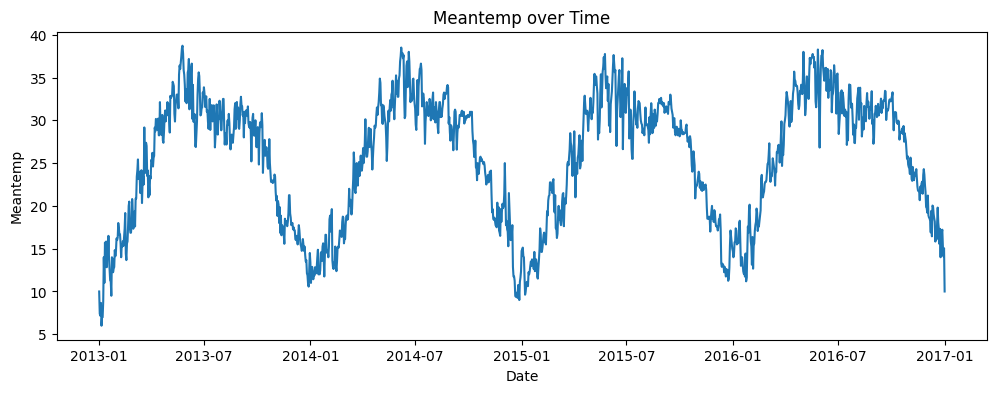

In [4]:
# TODO 3.1: Rename 'date' -> 'ds' and 'meantemp' -> 'y'.
df = df.rename(columns={'date': 'ds', 'meantemp': 'y'})
# TODO 3.2: Convert 'ds' to datetime using pd.to_datetime().
df['ds'] = pd.to_datetime(df['ds'])

# TODO 3.3: Sort by 'ds' and reset the index.
prophet_df = df.sort_values('ds').reset_index(drop=True)

# TODO 3.4: Plot the raw y series using matplotlib to inspect trend and seasonality.
# Use fig, ax = plt.subplots(figsize=(12, 4)).
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prophet_df['ds'], prophet_df['y'])
ax.set_title('Meantemp over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Meantemp')
plt.show()


### `My interpretion`
#### **The Data from above graph have sesonallity every 1 year and have no big variations over time series**

### Task 4: Model Trial 1 — Baseline Prophet (Default Settings)
Fit Prophet with all default parameters. This is your baseline before any tuning.

In [5]:
# TODO 4.1: Instantiate Prophet() with default parameters and fit on prophet_df.
m1 = Prophet()
m1.fit(prophet_df)

# TODO 4.2: Create a future DataFrame for 365 days using make_future_dataframe().
future1 = m1.make_future_dataframe(periods=365)

# TODO 4.3: Generate forecast using model.predict().
forecast1 = m1.predict(future1)

# TODO 4.4: Display the last 5 rows of ['ds', 'yhat', 'yhat_lower', 'yhat_upper'].
print(forecast1[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


             ds       yhat  yhat_lower  yhat_upper
1822 2017-12-28  15.763757   12.921525   18.471093
1823 2017-12-29  15.666927   12.908974   18.244705
1824 2017-12-30  15.534868   12.837072   18.014991
1825 2017-12-31  15.394141   12.701396   18.135544
1826 2018-01-01  15.582815   13.038316   18.332375


### Task 5: Visualizing the Baseline Forecast
Use Prophet's built-in matplotlib plot functions to inspect the forecast and its components.

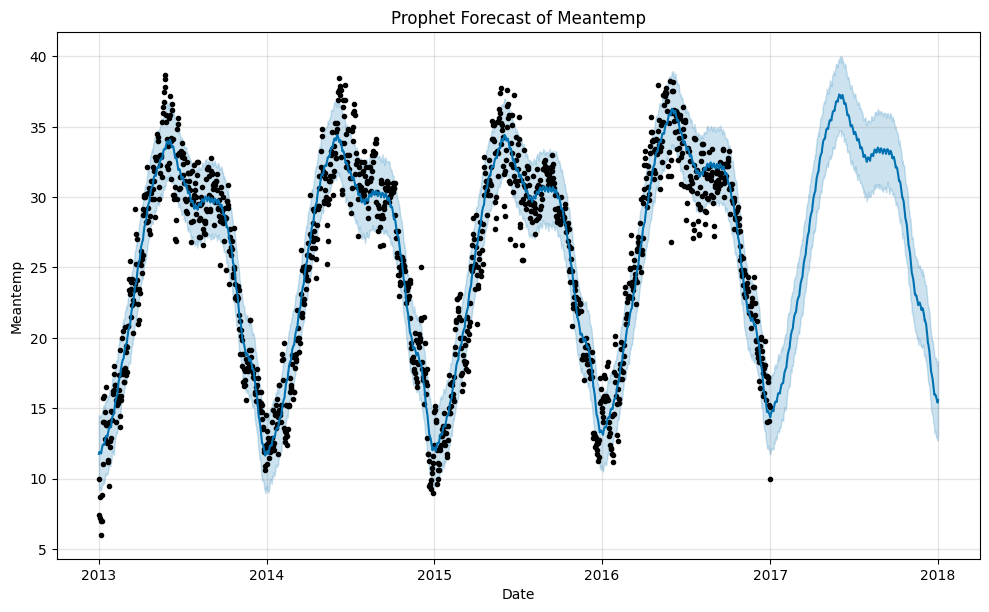

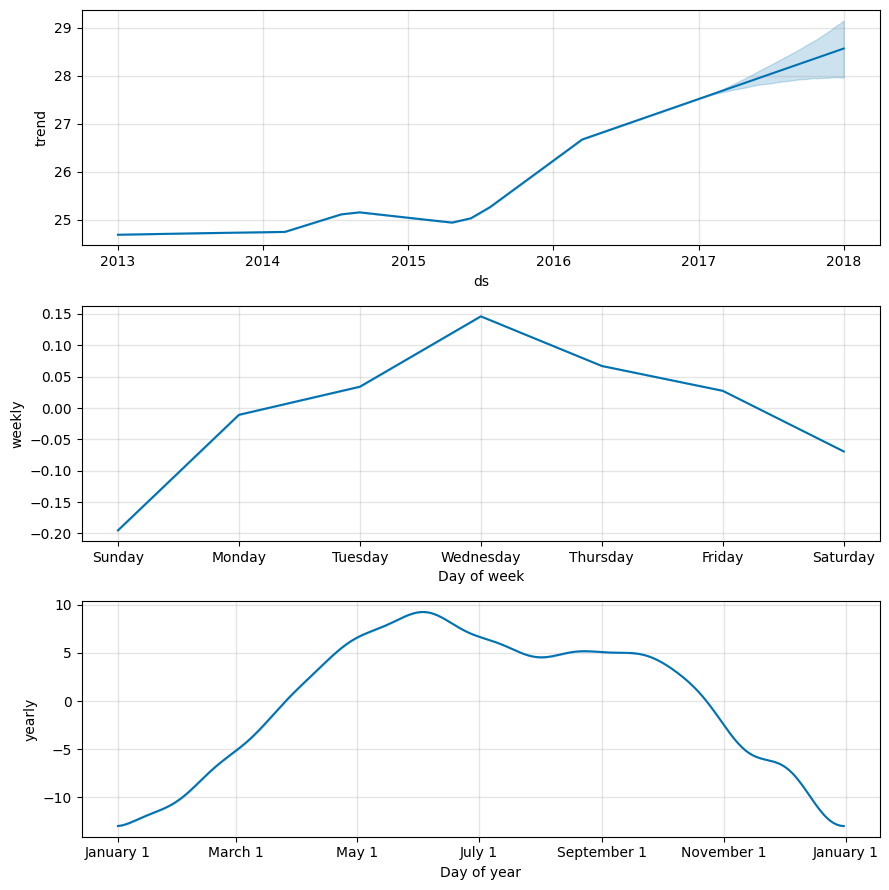

In [6]:
# TODO 5.1: Plot the full forecast using m1.plot(forecast1).
# Add a title and axis labels via the returned axes object.
fig1 = m1.plot(forecast1)
ax = fig1.gca()
ax.set_title('Prophet Forecast of Meantemp')
ax.set_xlabel('Date')
ax.set_ylabel('Meantemp')
# TODO 5.2: Plot the decomposed components using m1.plot_components(forecast1).
# Observe: trend, weekly seasonality, yearly seasonality.
fig2 = m1.plot_components(forecast1)
plt.tight_layout()
plt.show()


#### `My interpretion`
#### **In First Year from 2013 to 2014 we find that trend is fixed and start to grow this indicte that model not linear why to say this because there is non-linear tybe from prophet that handle non-linear data using logisitc function**
#### **For seasoanllity part we can see that data have sesonallity `yearly` and `weakly`**

### Task 6: Model Trial 2 — Tuning Growth and Changepoints
Explore how `changepoint_prior_scale` affects trend flexibility.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


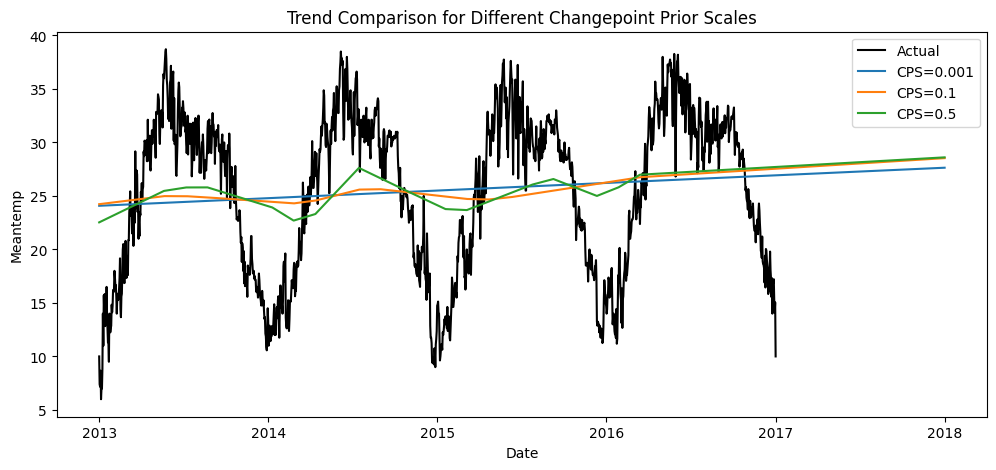

In [7]:
# TODO 6.1: Fit three Prophet models with changepoint_prior_scale = [0.001, 0.1, 0.5].
# Store trend forecasts in a dict: {scale_value: forecast_df}.
cps_results = {}

for cps in [0.001, 0.1, 0.5]:
    m = Prophet(changepoint_prior_scale=cps)
    m.fit(prophet_df)
    cps_results[cps] = m.predict(m.make_future_dataframe(periods=365))

# TODO 6.2: Plot all three trend lines on a single matplotlib figure (figsize=(12, 5)).
# Overlay the actual y series in black for reference.
# Label each trend line with its changepoint_prior_scale value in the legend.
plt.figure(figsize=(12, 5))
plt.plot(prophet_df['ds'], prophet_df['y'], color='black', label='Actual')
for cps, forecast in cps_results.items():
    plt.plot(forecast['ds'], forecast['trend'], label=f'CPS={cps}')
plt.title('Trend Comparison for Different Changepoint Prior Scales')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.legend()
plt.show()


#### `My interpretion`
#### **All Prior scales given in cell above don't capture data pattern we need to increase the prior scale**

### Task 7: Model Trial 3 — Custom Seasonality
Disable Prophet's default seasonalities and define explicit ones using `add_seasonality()`.

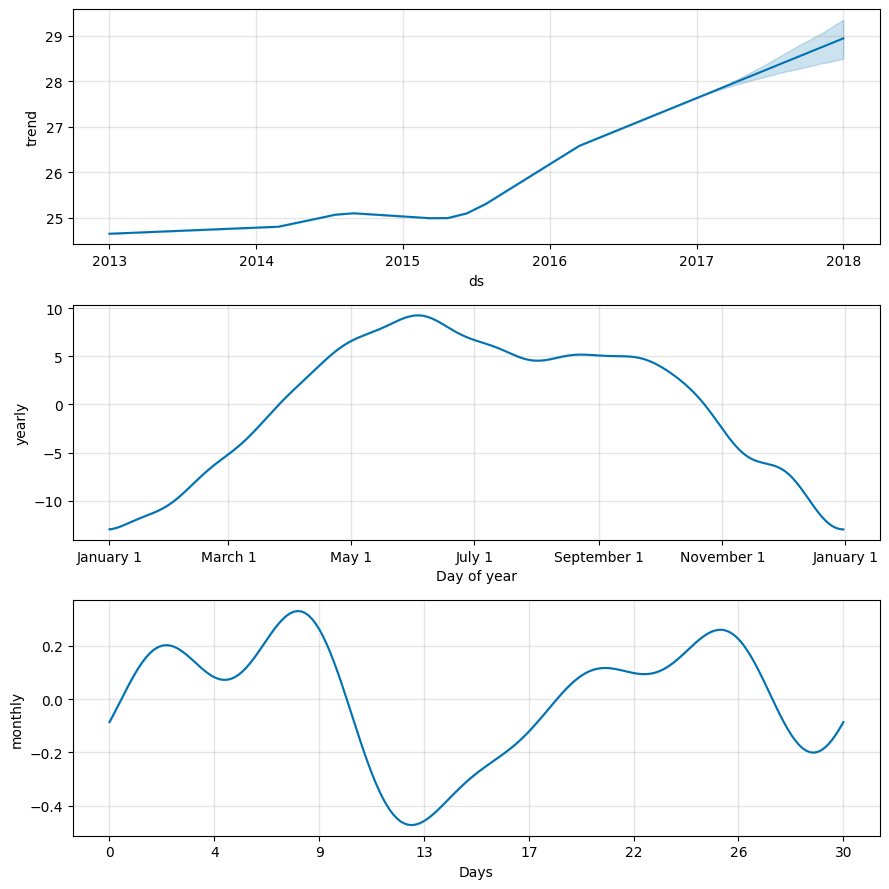

In [8]:
# TODO 7.1: Instantiate Prophet with daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False.
m3 = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
# TODO 7.2: Add a yearly seasonality using add_seasonality() with period=365.25 and fourier_order=10.
m3.add_seasonality(name='yearly', period=365.25, fourier_order=10)
# TODO 7.3: Add a monthly seasonality with period=30.5 and fourier_order=5.
m3.add_seasonality(name='monthly', period=30.5, fourier_order=5)
# TODO 7.4: Fit, forecast 365 days, and call m3.plot_components(forecast3) to inspect seasonality.
m3.fit(prophet_df)
forecast3 = m3.predict(m3.make_future_dataframe(periods=365))
m3.plot_components(forecast3)
plt.tight_layout()
plt.show()


### My Interpretion is that this data contain **Strong Yearly Seasonallity and Weakly Montly Seasonallity and upword increasing trend**
### `From this cell the conclusion is that this data dominated by yearly seasonallity and semi - linear up word trend`

### Task 8: Model Trial 4 — Adding External Regressors
Prophet supports additional regressors that can improve forecast accuracy.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


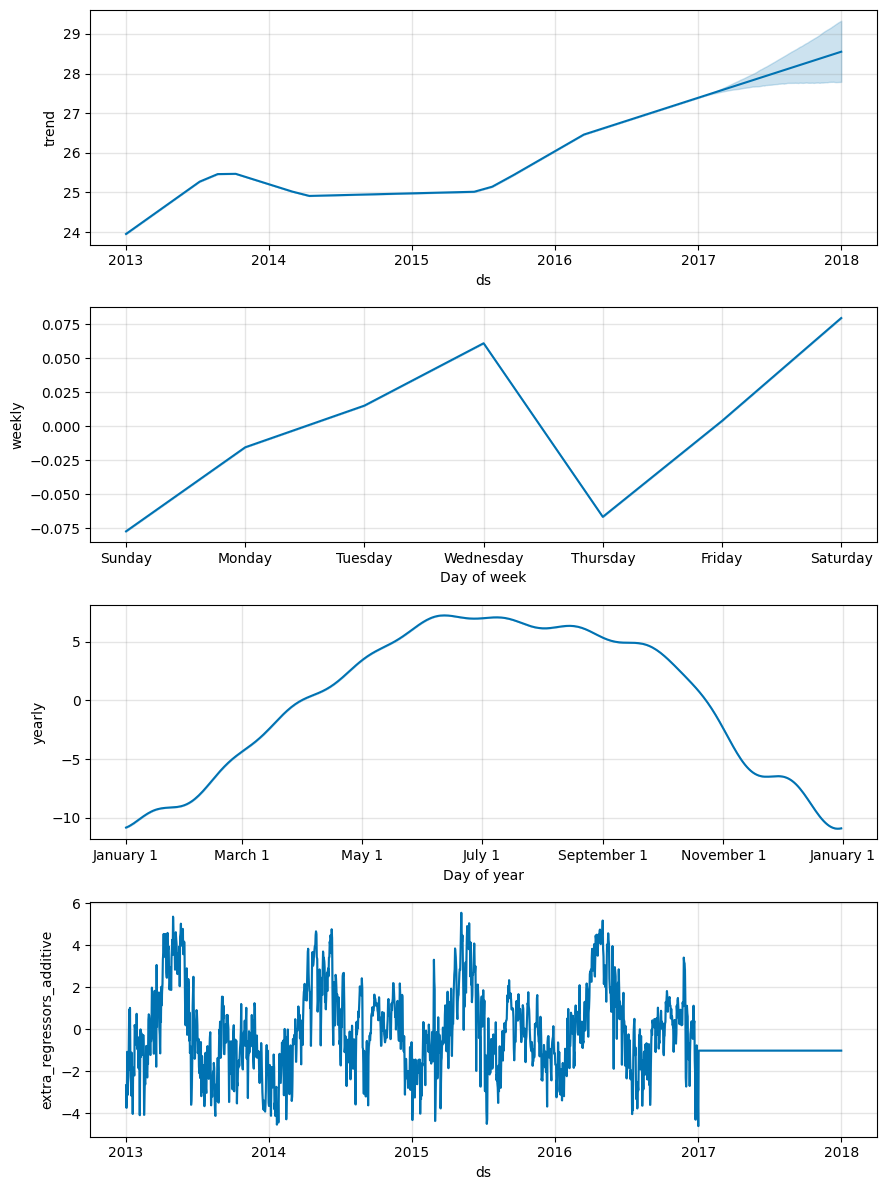

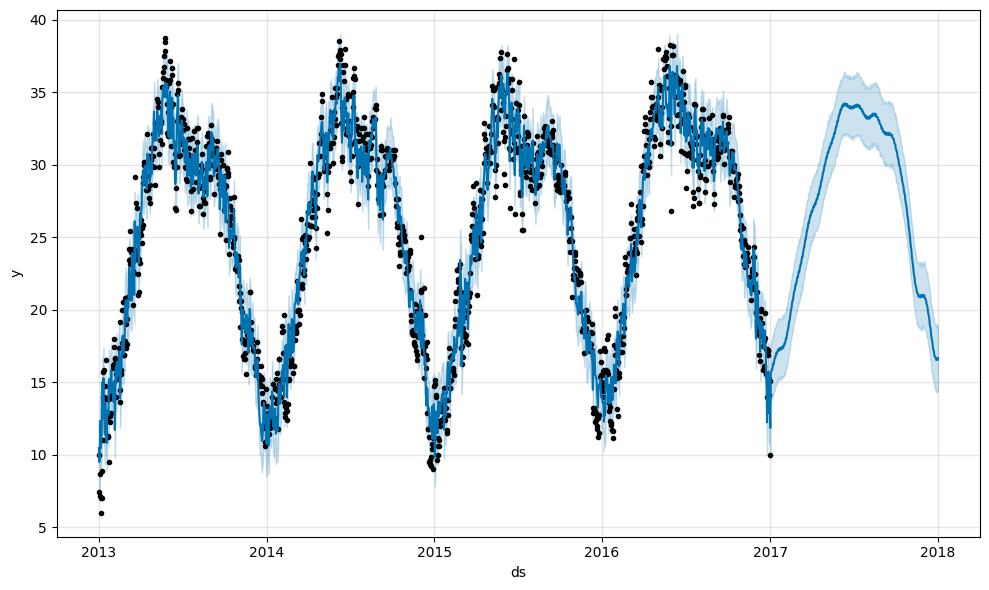

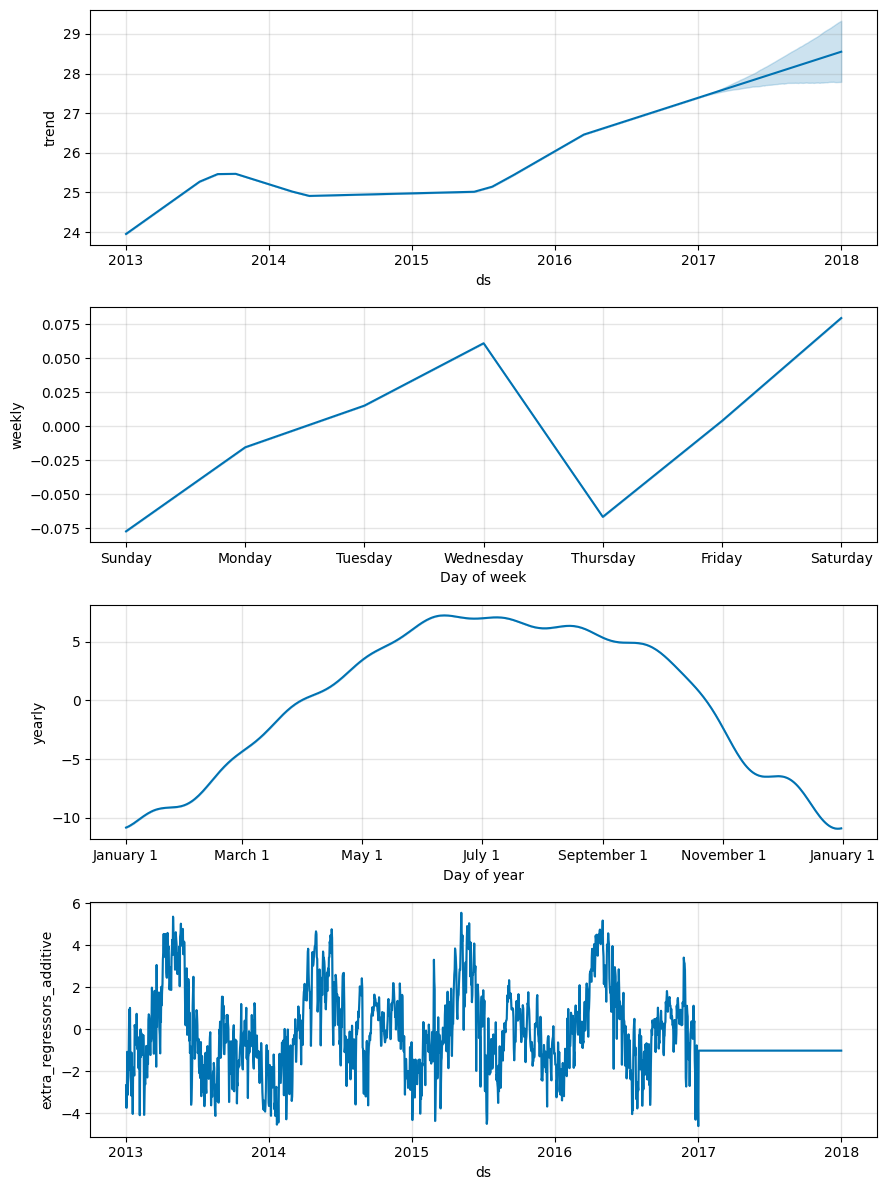

In [9]:
prophet_df_reg = prophet_df[['ds', 'y', 'humidity', 'wind_speed']]

m4 = Prophet()
m4.add_regressor('humidity')
m4.add_regressor('wind_speed')

m4.fit(prophet_df_reg)

future4 = m4.make_future_dataframe(periods=365)

# Merge historical regressors into future4. This will create NaN for future dates.
future4 = pd.merge(future4, prophet_df_reg[['ds', 'humidity', 'wind_speed']], on='ds', how='left')

# Calculate the 30-day rolling mean on the training data (prophet_df_reg)
# Using min_periods=1 to ensure we get a value even if less than 30 days are available at the start.
rolling_humidity = prophet_df_reg['humidity'].rolling(window=30, min_periods=1).mean()
rolling_wind_speed = prophet_df_reg['wind_speed'].rolling(window=30, min_periods=1).mean()

# Get the last valid rolling mean values from the training data to use as a proxy for future dates
last_humidity_rolling_mean = rolling_humidity.iloc[-1]
last_wind_speed_rolling_mean = rolling_wind_speed.iloc[-1]

# Fill the NaN values (corresponding to future dates) in future4 with these last rolling mean proxies
future4['humidity'] = future4['humidity'].fillna(last_humidity_rolling_mean)
future4['wind_speed'] = future4['wind_speed'].fillna(last_wind_speed_rolling_mean)

# Ensure the regressor columns are numeric, as Prophet expects this.
future4['humidity'] = pd.to_numeric(future4['humidity'])
future4['wind_speed'] = pd.to_numeric(future4['wind_speed'])

forecast4 = m4.predict(future4)
m4.plot(forecast4)
m4.plot_components(forecast4)

### My Interpretion from code I leave the deafult hyber parameter in Prophet model whis is auto for all kind of seasonallity of `Yearly , monthly, Weakly` the trend when adding reggresor is still liner up-trend yearly - seasonallity is still dominated weakly seasonality is Flactuate the forecasting is consider logic and seem promising

### Task 9: Changepoint Visualization
Identify where Prophet detected the most significant trend shifts and overlay them on the series.

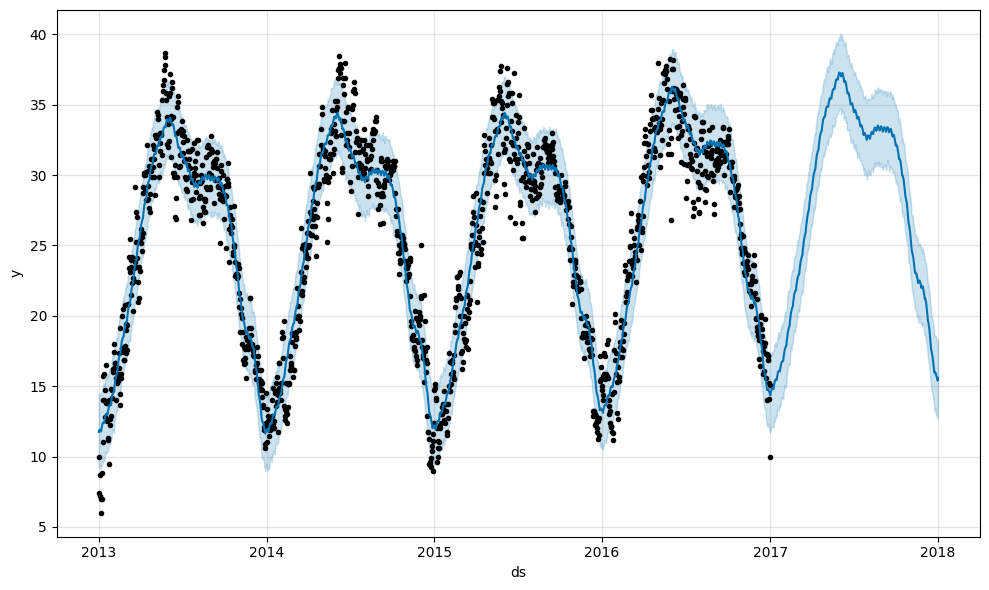

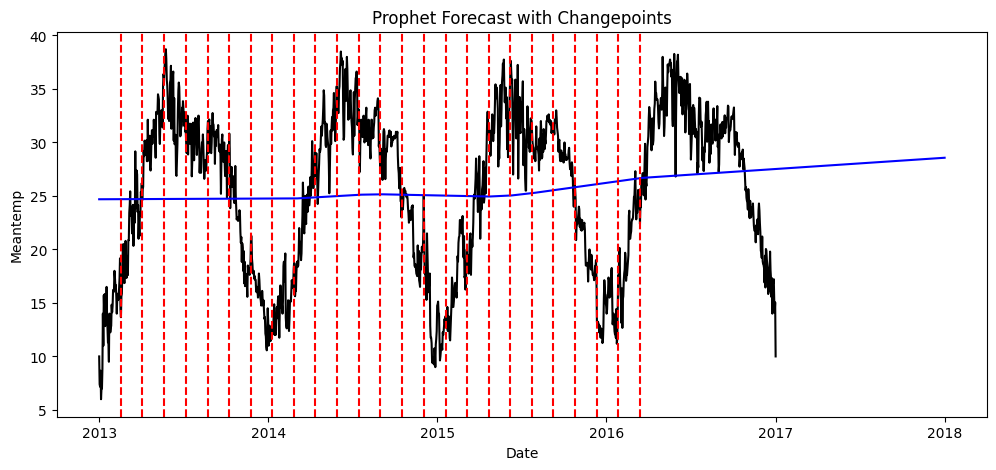

In [10]:
# TODO 9.1: Access m1.changepoints and m1.params['delta'] (trend rate changes).
# Print the top 5 changepoints sorted by abs(delta) descending.
changepoints = m1.changepoints
trend_rates = m1.params['delta']

# TODO 9.2: Build a matplotlib figure (figsize=(12, 5)) that overlays:
# - The actual y series in black
# - The forecast trend from forecast1 in blue
# - Vertical dashed red lines at each detected changepoint
# Add a legend and title.
m1.plot(forecast1)
plt.figure(figsize=(12, 5))
plt.plot(prophet_df['ds'], prophet_df['y'], color='black', label='Actual')
plt.plot(forecast1['ds'], forecast1['trend'], color='blue', label='Trend')
for cp in changepoints:
    plt.axvline(x=cp, color='red', linestyle='--', label='Changepoint')
plt.title('Prophet Forecast with Changepoints')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.show()


### `My Interpretion` The series is highly seasonal, with modest trend changes, and forecast uncertainty increases with horizon.

### Althoght We can Observe that chamgepoint is affected by years and this indicate yearly seasonallity

### Task 10: Cross-Validation
Use Prophet's built-in time-series cross-validation to evaluate generalization.

In [11]:
# TODO 10.1: Run cross_validation() on m1 with:
# - initial='730 days'
# - period='180 days'
# - horizon='365 days'
df_cv = cross_validation(m1, initial='730 days', period='180 days', horizon='365 days')

# TODO 10.2: Print df_cv.head() and list the unique cutoff dates.
print(df_cv.head())
print(df_cv['cutoff'].unique())


INFO:prophet:Making 3 forecasts with cutoffs between 2015-01-07 00:00:00 and 2016-01-02 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

          ds       yhat  yhat_lower  yhat_upper       y     cutoff
0 2015-01-08  12.371727   10.061919   14.925488  10.000 2015-01-07
1 2015-01-09  12.432036    9.880491   15.175885  10.625 2015-01-07
2 2015-01-10  12.630032   10.217051   15.002474  11.125 2015-01-07
3 2015-01-11  12.753647   10.263566   15.236951  11.000 2015-01-07
4 2015-01-12  13.260087   10.975733   15.795780  10.625 2015-01-07
<DatetimeArray>
['2015-01-07 00:00:00', '2015-07-06 00:00:00', '2016-01-02 00:00:00']
Length: 3, dtype: datetime64[ns]


### From Cuttof we see that data cross validatio cutoffpoints is controlled by 6 month `half yearly seasonallity`






### Task 11: Performance Metrics
Compute rolling performance metrics across the cross-validation horizon.

Index(['horizon', 'mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage'], dtype='object')
  horizon       mse      rmse       mae      mape     mdape     smape  \
0 37 days  5.798027  2.407909  1.871573  0.112701  0.076104  0.111299   
1 38 days  5.689194  2.385203  1.850204  0.110541  0.069593  0.109223   
2 39 days  5.551631  2.356190  1.815403  0.108188  0.069593  0.106806   
3 40 days  5.348745  2.312735  1.794891  0.106396  0.069593  0.105093   
4 41 days  4.930436  2.220459  1.746231  0.102992  0.069593  0.101937   
5 42 days  4.498545  2.120977  1.672747  0.098838  0.066981  0.098042   
6 43 days  4.504382  2.122353  1.664024  0.097384  0.065770  0.096819   
7 44 days  4.615860  2.148455  1.655915  0.095986  0.064526  0.095567   
8 45 days  4.676253  2.162465  1.652075  0.095129  0.063228  0.094751   
9 46 days  4.688910  2.165389  1.662582  0.094857  0.063228  0.094348   

   coverage  
0  0.706422  
1  0.712538  
2  0.718654  
3  0.718654  
4  0.733945  
5  0.746177  
6  

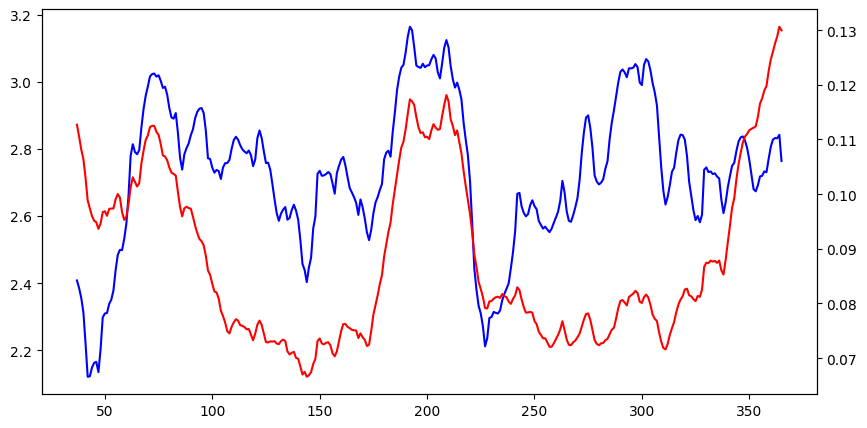

In [12]:
# TODO 11.1: Run performance_metrics(df_cv, rolling_window=0.1) and assign to df_perf.
df_perf = performance_metrics(df_cv, rolling_window=0.1)

# TODO 11.2: Print available columns and display the first 10 rows.
print(df_perf.columns)
print(df_perf.head(10))

# TODO 11.3: Plot RMSE and MAPE vs horizon on a single matplotlib figure with two y-axes.
# Use fig, ax1 = plt.subplots(figsize=(10, 5)) and ax2 = ax1.twinx().
# Convert horizon to days using .dt.days for the x-axis.
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df_perf['horizon'].dt.days, df_perf['rmse'], color='blue', label='RMSE')
ax2.plot(df_perf['horizon'].dt.days, df_perf['mape'], color='red', label="MAPE")
plt.show()

### We can obeserve from error plotting that model is make low error till day 50 ~37:47 and gradually start to increase and reach minimum value at day 140 the model is moderate error
### We can also see that `RMSE` from day ~250 to ~350 is have high difference between `MAPE` which indicate that model need to be tuned model to get boosted perfoemance

### Task 12: Model Comparison — RMSE Across Trials
Compare the in-sample RMSE of all model trials against a naive mean baseline.

In [13]:
naive_rmse = np.sqrt(((prophet_df['y'] - prophet_df['y'].mean()) ** 2).mean())


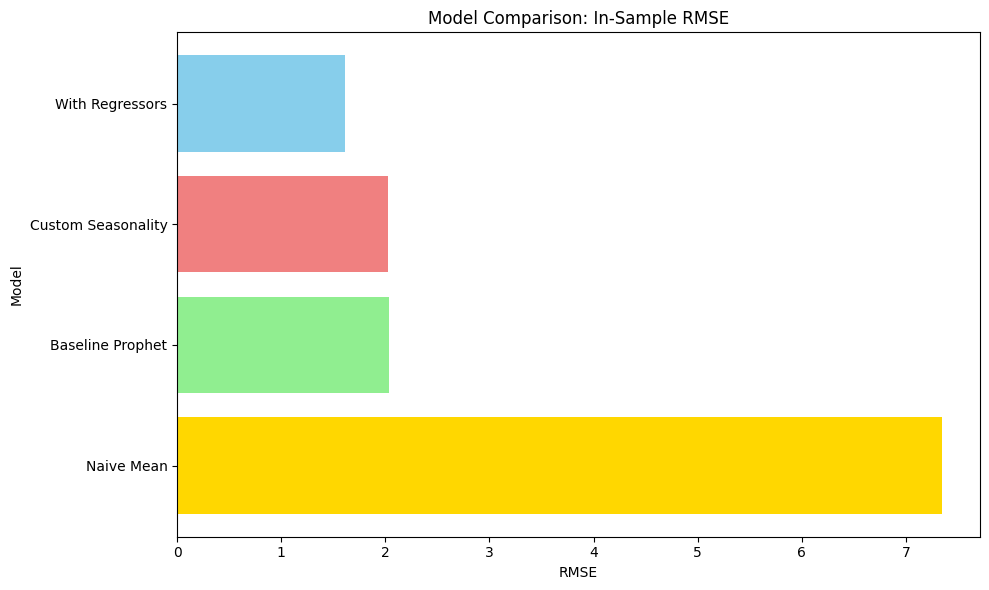

In [15]:
merged_df1 = forecast1[['ds', 'yhat']].merge(prophet_df, on='ds', how='inner')
rmse1 = np.sqrt(((merged_df1['y'] - merged_df1['yhat']) ** 2).mean())

merged_df3 = forecast3[['ds', 'yhat']].merge(prophet_df, on='ds', how='inner')
rmse3 = np.sqrt(((merged_df3['y'] - merged_df3['yhat']) ** 2).mean())

# For m4, merge with prophet_df_reg as it contains the regressors
merged_df4 = forecast4[['ds', 'yhat']].merge(prophet_df_reg, on='ds', how='inner')
rmse4 = np.sqrt(((merged_df4['y'] - merged_df4['yhat']) ** 2).mean())

# TODO 12.2: Compute the naive baseline RMSE using the global mean of y as the prediction.
# This was already computed in the previous cell, so we'll just use the existing variable.

# Store all RMSE values in a dictionary
rmse_values = {
    'Baseline Prophet': rmse1,
    'Custom Seasonality': rmse3,
    'With Regressors': rmse4,
    'Naive Mean': naive_rmse
}

# Sort bars from lowest to highest RMSE.
sorted_rmse = sorted(rmse_values.items(), key=lambda x: x[1])
labels = [item[0] for item in sorted_rmse]
values = [item[1] for item in sorted_rmse]

# TODO 12.3: Plot a horizontal bar chart with matplotlib comparing RMSE across:
# ['Baseline Prophet', 'Custom Seasonality', 'With Regressors', 'Naive Mean']
# Sort bars from lowest to highest RMSE.
plt.figure(figsize=(10, 6))
plt.barh(labels, values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.title('Model Comparison: In-Sample RMSE')
plt.gca().invert_yaxis() # Display lowest RMSE at the top
plt.tight_layout()
plt.show()

### From this graphe we can couclude that `added Regrssor` Model achieve higher performace due to adding boosting regressor

### Task 13: Final Forecast with Prediction Intervals
Load the test set and evaluate your best model's out-of-sample forecast with uncertainty bands.

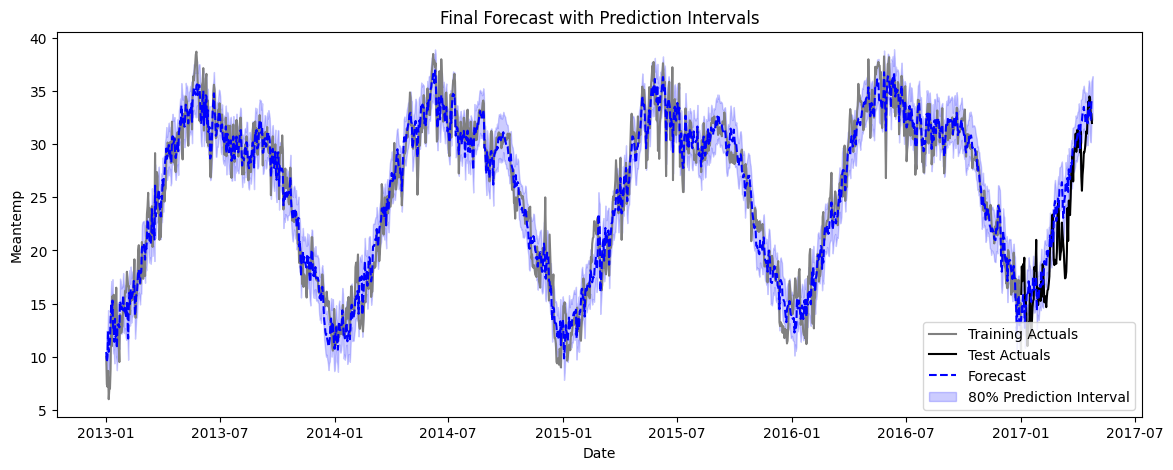

Test RMSE: 3.2446
Test MAPE: 0.1360


In [28]:
# TODO 13.1: Load 'DailyDelhiClimateTest.csv'. Rename 'date' -> 'ds', 'meantemp' -> 'y'.
df_test = pd.read_csv(path + "/DailyDelhiClimateTest.csv")
df_test = df_test.rename(columns={'date': 'ds', 'meantemp': 'y'})
df_test['ds'] = pd.to_datetime(df_test['ds'])

# TODO 13.2: Using your best model (m4), generate a forecast that covers the test period.
future_test = m4.make_future_dataframe(periods=len(df_test))

# Merge test set regressors
future_test = pd.merge(future_test, df_test[['ds', 'humidity', 'wind_speed']], on='ds', how='left')

# Merge training set regressors to fill historical gaps
future_test = pd.merge(future_test, prophet_df[['ds', 'humidity', 'wind_speed']], on='ds', how='left', suffixes=('', '_train'))
future_test['humidity'] = future_test['humidity'].fillna(future_test['humidity_train'])
future_test['wind_speed'] = future_test['wind_speed'].fillna(future_test['wind_speed_train'])
future_test = future_test.drop(columns=['humidity_train', 'wind_speed_train'])

# Fix: Handle any remaining NaNs (like the last day of the test set) by forward filling
future_test['humidity'] = future_test['humidity'].ffill()
future_test['wind_speed'] = future_test['wind_speed'].ffill()

forecast_final = m4.predict(future_test)

# Filter forecast for test period metrics
forecast_test_only = forecast_final[forecast_final['ds'].isin(df_test['ds'])]

# TODO 13.3: Build a matplotlib figure (figsize=(14, 5))
plt.figure(figsize=(14, 5))
plt.plot(prophet_df['ds'], prophet_df['y'], color='grey', label='Training Actuals')
plt.plot(df_test['ds'], df_test['y'], color='black', label='Test Actuals')
plt.plot(forecast_final['ds'], forecast_final['yhat'], color='blue', linestyle='--', label='Forecast')
plt.fill_between(forecast_final['ds'], forecast_final['yhat_lower'], forecast_final['yhat_upper'], alpha=0.2, color='blue', label='80% Prediction Interval')
plt.title('Final Forecast with Prediction Intervals')
plt.xlabel('Date')
plt.ylabel('Meantemp')
plt.legend()
plt.show()

# TODO 13.4: Compute and print test RMSE and MAPE.
# We align the lengths in case of any dropped rows or mismatches
common_dates = df_test.merge(forecast_test_only[['ds', 'yhat']], on='ds')
test_rmse = np.sqrt(((common_dates['y'] - common_dates['yhat']) ** 2).mean())
test_MAPE = np.mean(np.abs((common_dates['y'] - common_dates['yhat']) / common_dates['y']))

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAPE: {test_MAPE:.4f}")

### Task 14: Model Serialization
Save your best model to disk using Prophet's JSON serialization for reproducibility.

In [29]:
import json
# TODO 14.1: Import model_to_json and model_from_json from prophet.serialize.
from prophet.serialize import model_to_json, model_from_json

# TODO 14.2: Serialize your best model to a JSON file named 'prophet_delhi_model.json'.
with open('prophet_delhi_model.json', 'w') as fout:
    fout.write(model_to_json(m4))

# TODO 14.3: Reload the model from the file using model_from_json.
with open('prophet_delhi_model.json', 'r') as fin:
    m4_reloaded = model_from_json(fin.read())

# TODO 14.4: Run predict() on the loaded model and verify yhat matches the original
# by printing the max absolute delta between the two forecast yhat columns.
forecast_reloaded = m4_reloaded.predict(future_test)
delta = np.abs(forecast_final['yhat'] - forecast_reloaded['yhat']).max()

print(f"Max absolute delta between original and reloaded yhat: {delta}")
if delta < 1e-6:
    print("Serialization successful: The reloaded model produces identical forecasts.")

Max absolute delta between original and reloaded yhat: 0.0
Serialization successful: The reloaded model produces identical forecasts.
